# Notebook 2: Testing XAI Method Implementations
This notebook tests all your XAI implementations including the aggregated Grad-CAM.

In [1]:
import os
import sys

# Change working directory to project root
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

# Add src to path if not already handled
if 'src' not in sys.path:
    sys.path.append('src')

print(f"Current working directory: {os.getcwd()}")

Current working directory: /Users/manue/Desktop/final-project-rdgzmanuel


In [2]:
import sys
sys.path.append('../src')

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from data_preprocessing import load_splits, GTSRBDataset, get_transforms, GTSRBConfig
from models import get_model
from xai_methods import GradCAM, IntegratedGradients, OcclusionSensitivity, XAIEvaluator, get_target_layer
from utils import denormalize_image, overlay_heatmap, plot_xai_comparison, GTSRB_CLASS_NAMES
from torch.utils.data import DataLoader

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


## Setup: Load Model and Data

In [3]:
# Load a trained model (or use untrained for testing)
# For testing, we'll use an untrained model - replace with trained model path for real analysis
model_name = 'mobilenet'
model = get_model(model_name, num_classes=43, pretrained=True, device=device)

# If you have a trained model, load it:
# model.load_state_dict(torch.load('../models/mobilenet_phase2.pth'))

model.eval()
print(f"✓ Model loaded: {model_name}")

✓ Model loaded: mobilenet


In [4]:
# Load test data
processed_dir = Path('data/processed')
splits = load_splits(processed_dir)

test_dataset = GTSRBDataset(
    splits['test'][0][:500],  # Use subset for testing
    splits['test'][1][:500],
    transform=get_transforms(augment=False)
)

test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
print(f"✓ Test dataset size: {len(test_dataset)}")

✓ Test dataset size: 500


Sample image:
  True label: 1 (Speed limit (30km/h))
  Predicted: 23 (Slippery road)
  Confidence: 0.0744


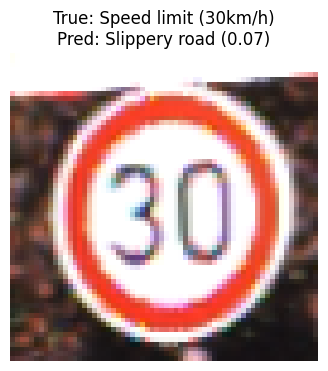

In [5]:
# Get a sample image for testing
sample_idx = 0
sample_image, sample_label = test_dataset[sample_idx]
sample_input = sample_image.unsqueeze(0).to(device)

# Get prediction
with torch.no_grad():
    output = model(sample_input)
    probs = torch.softmax(output, dim=1)
    pred_class = torch.argmax(output, dim=1).item()
    confidence = probs[0, pred_class].item()

print(f"Sample image:")
print(f"  True label: {sample_label} ({GTSRB_CLASS_NAMES[sample_label]})")
print(f"  Predicted: {pred_class} ({GTSRB_CLASS_NAMES[pred_class]})")
print(f"  Confidence: {confidence:.4f}")

# Visualize
img_denorm = denormalize_image(sample_image)
plt.figure(figsize=(4, 4))
plt.imshow(img_denorm)
plt.title(f"True: {GTSRB_CLASS_NAMES[sample_label]}\nPred: {GTSRB_CLASS_NAMES[pred_class]} ({confidence:.2f})")
plt.axis('off')
plt.show()

## 1. Test Grad-CAM (Local Explanation)

Testing Grad-CAM...
✓ Target layer: Conv2dNormActivation(
  (0): Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU6(inplace=True)
)
✓ Grad-CAM instance created
✓ CAM generated, shape: (64, 64)
✓ CAM range: [0.0000, 1.0000]


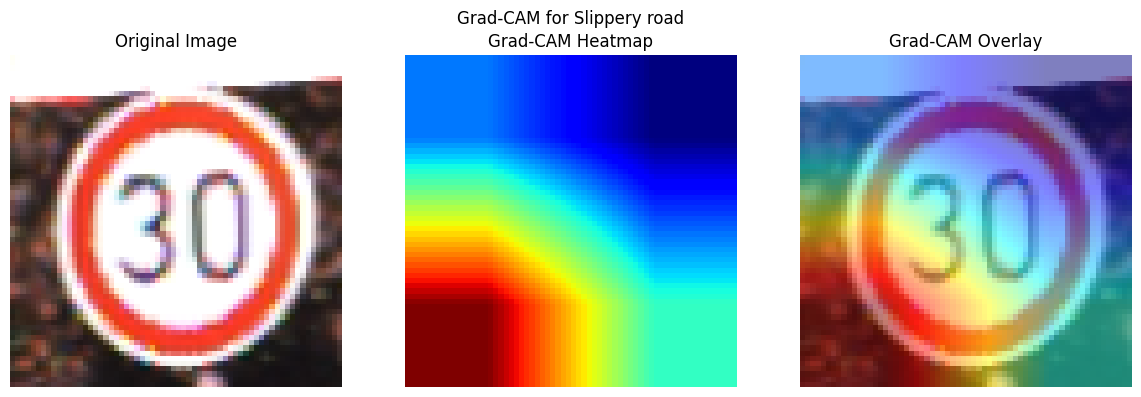


✅ Grad-CAM is working!


In [ ]:
print("Testing Grad-CAM...")

# Get target layer
target_layer = get_target_layer(model, model_name)
print(f"✓ Target layer: {target_layer}")

# Create Grad-CAM instance
gradcam = GradCAM(model, target_layer)
print("✓ Grad-CAM instance created")

# Generate CAM for predicted class
cam = gradcam.generate_cam(sample_input, target_class=pred_class)
print(f"✓ CAM generated, shape: {cam.shape}")
print(f"✓ CAM range: [{cam.min():.4f}, {cam.max():.4f}]")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img_denorm)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(cam, cmap='jet')
axes[1].set_title('Grad-CAM Heatmap')
axes[1].axis('off')

overlayed = overlay_heatmap(img_denorm, cam)
axes[2].imshow(overlayed)
axes[2].set_title('Grad-CAM Overlay')
axes[2].axis('off')

plt.suptitle(f'Grad-CAM for {GTSRB_CLASS_NAMES[pred_class]}')
plt.tight_layout()
plt.show()

print("\nGrad-CAM is working!")

## 2. Test Aggregated Grad-CAM (Global Explanation)

Testing Aggregated Grad-CAM...
Generating aggregated CAM for class 14: Stop
Using 20 samples...
✓ Aggregated CAM generated, shape: (64, 64)
✓ Aggregated CAM range: [0.0036, 1.0000]


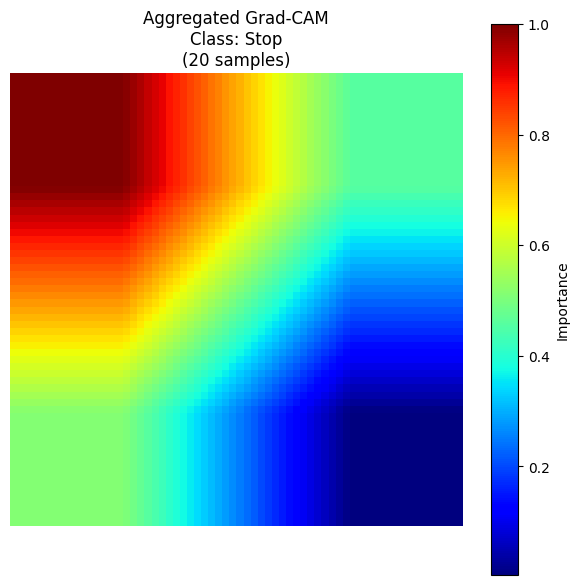


✅ Aggregated Grad-CAM is working!


In [ ]:
print("Testing Aggregated Grad-CAM...")

# Select a class to analyze (e.g., class 14 = Stop sign)
target_class_id = 14
num_samples = 20

print(f"Generating aggregated CAM for class {target_class_id}: {GTSRB_CLASS_NAMES[target_class_id]}")
print(f"Using {num_samples} samples...")

# Generate aggregated CAM
aggregated_cam = gradcam.generate_aggregated_cam(
    test_loader,
    class_id=target_class_id,
    num_samples=num_samples
)

print(f"✓ Aggregated CAM generated, shape: {aggregated_cam.shape}")
print(f"✓ Aggregated CAM range: [{aggregated_cam.min():.4f}, {aggregated_cam.max():.4f}]")

# Visualize
plt.figure(figsize=(6, 6))
plt.imshow(aggregated_cam, cmap='jet')
plt.colorbar(label='Importance')
plt.title(f'Aggregated Grad-CAM\nClass: {GTSRB_CLASS_NAMES[target_class_id]}\n({num_samples} samples)')
plt.axis('off')
plt.tight_layout()
plt.show()

print("\nAggregated Grad-CAM is working!")

## 3. Test Aggregated Grad-CAM for Multiple Classes

Generating aggregated CAMs for multiple classes...
Processing class 1: Speed limit (30km/h)...
Processing class 2: Speed limit (50km/h)...
Processing class 13: Yield...
Processing class 14: Stop...
Processing class 17: No entry...
Processing class 38: Keep right...


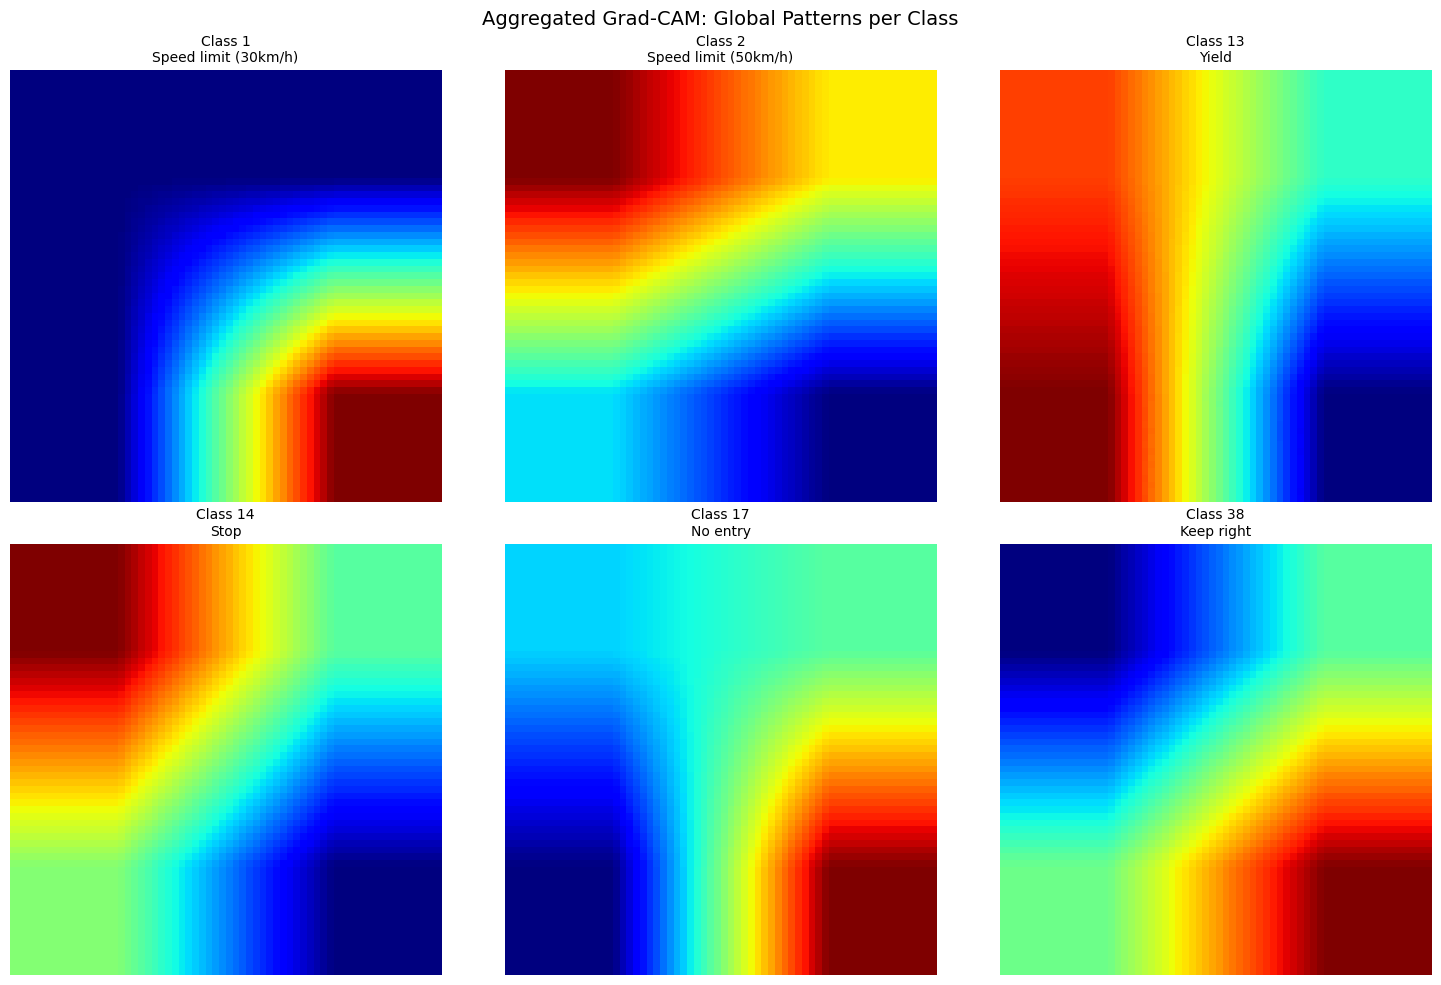


✅ Multi-class aggregated Grad-CAM is working!


In [ ]:
print("Generating aggregated CAMs for multiple classes...")

# Select interesting classes
classes_to_analyze = [1, 2, 13, 14, 17, 38]  # Different speed limits, yield, stop, no entry, keep right
aggregated_cams = {}

for class_id in classes_to_analyze:
    print(f"Processing class {class_id}: {GTSRB_CLASS_NAMES[class_id]}...")
    agg_cam = gradcam.generate_aggregated_cam(
        test_loader,
        class_id=class_id,
        num_samples=15
    )
    aggregated_cams[class_id] = agg_cam

# Visualize all
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, class_id in enumerate(classes_to_analyze):
    axes[idx].imshow(aggregated_cams[class_id], cmap='jet')
    axes[idx].set_title(f'Class {class_id}\n{GTSRB_CLASS_NAMES[class_id]}', fontsize=10)
    axes[idx].axis('off')

plt.suptitle('Aggregated Grad-CAM: Global Patterns per Class', fontsize=14)
plt.tight_layout()
plt.show()

print("\nMulti-class aggregated Grad-CAM is working!")

## 4. Test Integrated Gradients

Testing Integrated Gradients...
✓ Integrated Gradients instance created


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.16032508..0.15505391].


✓ Attribution generated, shape: (64, 64, 3)
✓ Attribution range: [-0.1603, 0.1551]
(64, 64, 3) (64, 64, 3)


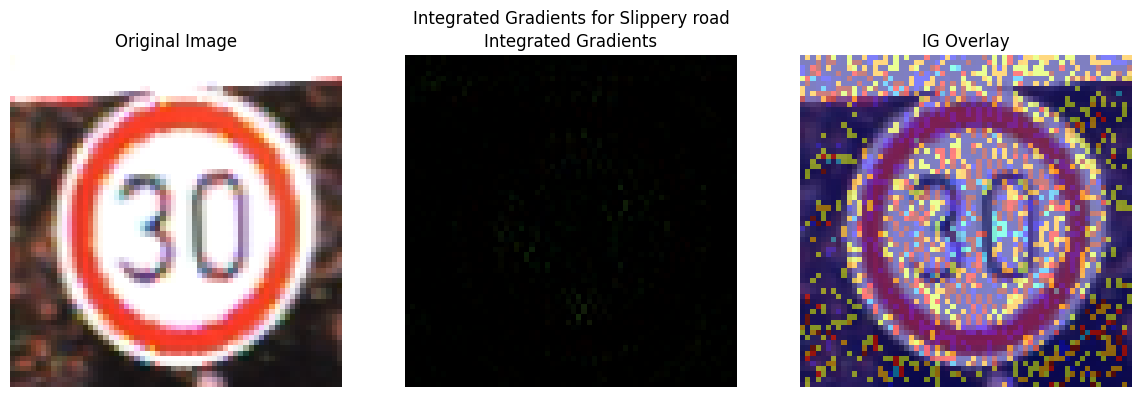


✅ Integrated Gradients is working!


In [9]:
print("Testing Integrated Gradients...")

# Create IG instance
ig = IntegratedGradients(model)
print("✓ Integrated Gradients instance created")

# Generate attribution
attribution = ig.generate_attribution(
    sample_input,
    target_class=pred_class,
    steps=50
)

print(f"✓ Attribution generated, shape: {attribution.shape}")
print(f"✓ Attribution range: [{attribution.min():.4f}, {attribution.max():.4f}]")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img_denorm)
axes[0].set_title('Original Image')
axes[0].axis('off')

print(img_denorm.shape, attribution.shape)

axes[1].imshow(attribution, cmap='jet')
axes[1].set_title('Integrated Gradients')
axes[1].axis('off')

overlayed = overlay_heatmap(img_denorm, attribution)
axes[2].imshow(overlayed)
axes[2].set_title('IG Overlay')
axes[2].axis('off')

plt.suptitle(f'Integrated Gradients for {GTSRB_CLASS_NAMES[pred_class]}')
plt.tight_layout()
plt.show()

print("\nIntegrated Gradients is working!")

## 5. Test Occlusion Sensitivity

Testing Occlusion Sensitivity...
Note: This may take a minute as it slides a window over the image...
✓ Occlusion Sensitivity instance created
✓ Sensitivity map generated, shape: (64, 64)
✓ Sensitivity range: [-0.0676, 0.0350]


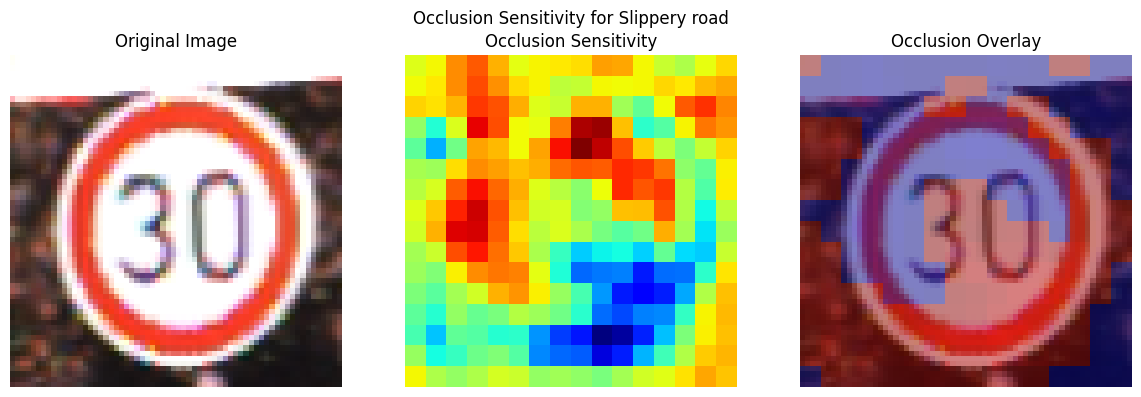


✅ Occlusion Sensitivity is working!


In [10]:
print("Testing Occlusion Sensitivity...")
print("Note: This may take a minute as it slides a window over the image...")

# Create Occlusion instance
occlusion = OcclusionSensitivity(
    model,
    occlusion_size=8,
    occlusion_stride=4,
    occlusion_value=0.5
)
print("✓ Occlusion Sensitivity instance created")

# Generate sensitivity map
sensitivity_map = occlusion.generate_sensitivity_map(
    sample_input,
    target_class=pred_class
)

print(f"✓ Sensitivity map generated, shape: {sensitivity_map.shape}")
print(f"✓ Sensitivity range: [{sensitivity_map.min():.4f}, {sensitivity_map.max():.4f}]")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img_denorm)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(sensitivity_map, cmap='jet')
axes[1].set_title('Occlusion Sensitivity')
axes[1].axis('off')

overlayed = overlay_heatmap(img_denorm, sensitivity_map)
axes[2].imshow(overlayed)
axes[2].set_title('Occlusion Overlay')
axes[2].axis('off')

plt.suptitle(f'Occlusion Sensitivity for {GTSRB_CLASS_NAMES[pred_class]}')
plt.tight_layout()
plt.show()

print("\nOcclusion Sensitivity is working!")

## 6. Test XAI Evaluator - Compare All Methods

Testing XAI Evaluator...
✓ XAI Evaluator instance created
✓ Comparison results:
  gradcam: shape (64, 64), range [0.0000, 1.0000]
  integrated_gradients: shape (64, 64, 3), range [-0.1603, 0.1551]
  occlusion: shape (64, 64), range [-0.0676, 0.0350]


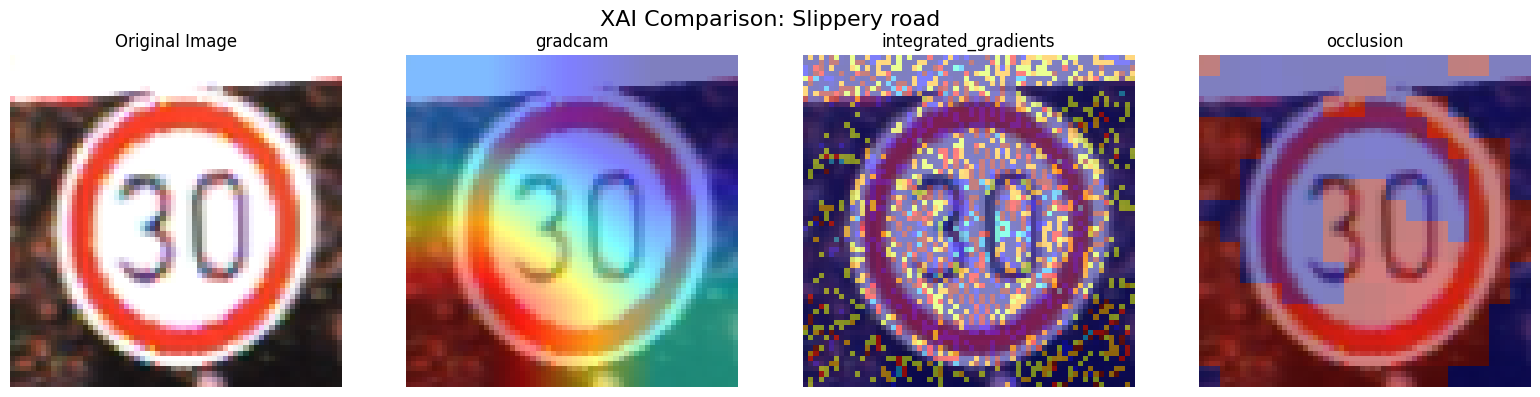


✅ XAI Evaluator is working!


In [11]:
print("Testing XAI Evaluator...")

# Create evaluator
evaluator = XAIEvaluator(model)
print("✓ XAI Evaluator instance created")

# Compare all methods
comparison_results = evaluator.compare_methods(
    sample_input,
    pred_class,
    gradcam,
    ig,
    occlusion
)

print("✓ Comparison results:")
for method, heatmap in comparison_results.items():
    print(f"  {method}: shape {heatmap.shape}, range [{heatmap.min():.4f}, {heatmap.max():.4f}]")

# Visualize comparison
plot_xai_comparison(
    img_denorm,
    comparison_results,
    title=f'XAI Comparison: {GTSRB_CLASS_NAMES[pred_class]}'
)

print("\nXAI Evaluator is working!")

## 7. Test Top-K Overlap

In [13]:
print("Testing top-k overlap...")

# Compute overlaps
overlap_gradcam_ig = evaluator.top_k_overlap(
    comparison_results['gradcam'],
    comparison_results['integrated_gradients'],
    k_percent=0.1
)

overlap_gradcam_occlusion = evaluator.top_k_overlap(
    comparison_results['gradcam'],
    comparison_results['occlusion'],
    k_percent=0.1
)

overlap_ig_occlusion = evaluator.top_k_overlap(
    comparison_results['integrated_gradients'],
    comparison_results['occlusion'],
    k_percent=0.1
)

print(f"✓ Grad-CAM vs IG top-10% overlap: {overlap_gradcam_ig:.4f}")
print(f"✓ Grad-CAM vs Occlusion top-10% overlap: {overlap_gradcam_occlusion:.4f}")
print(f"✓ IG vs Occlusion top-10% overlap: {overlap_ig_occlusion:.4f}")

print("\nTop-k overlap is working!")

Testing top-k overlap...
✓ Grad-CAM vs IG top-10% overlap: 0.0049
✓ Grad-CAM vs Occlusion top-10% overlap: 0.0000
✓ IG vs Occlusion top-10% overlap: 0.0523

✅ Top-k overlap is working!


## 9. Comprehensive Test: Multiple Samples

Testing on multiple samples...


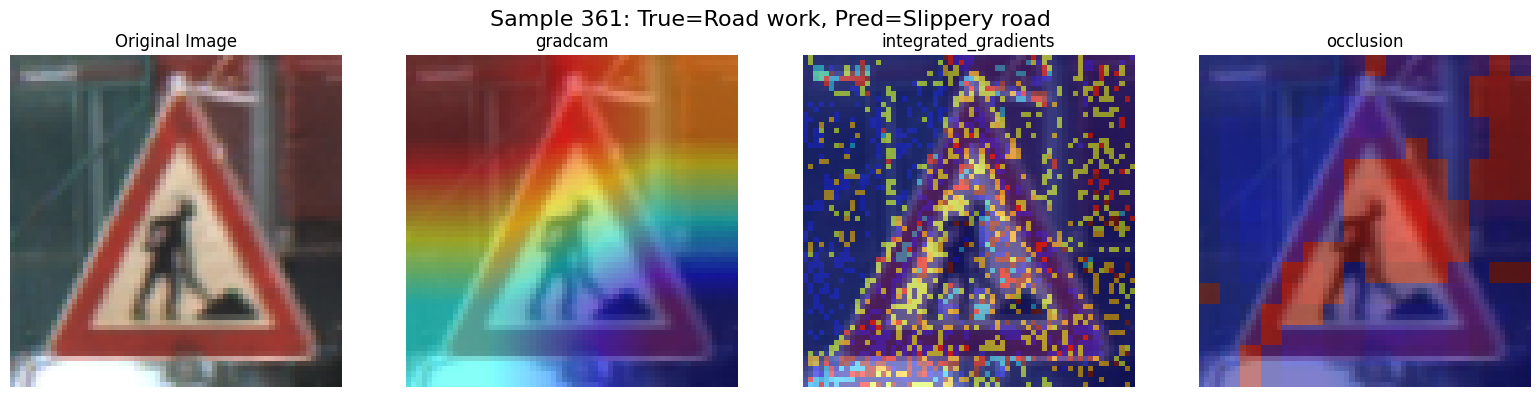

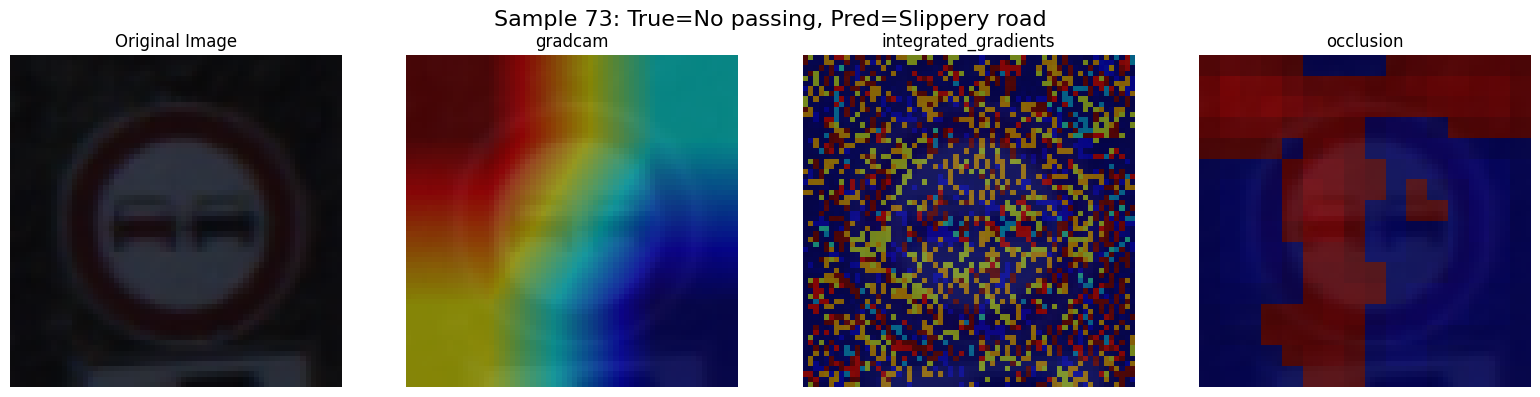

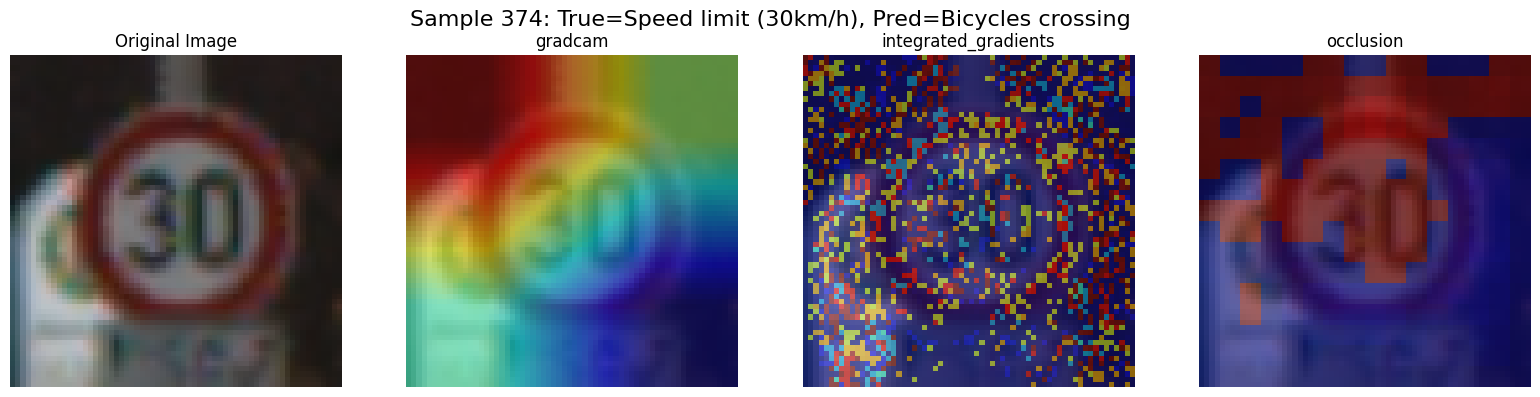

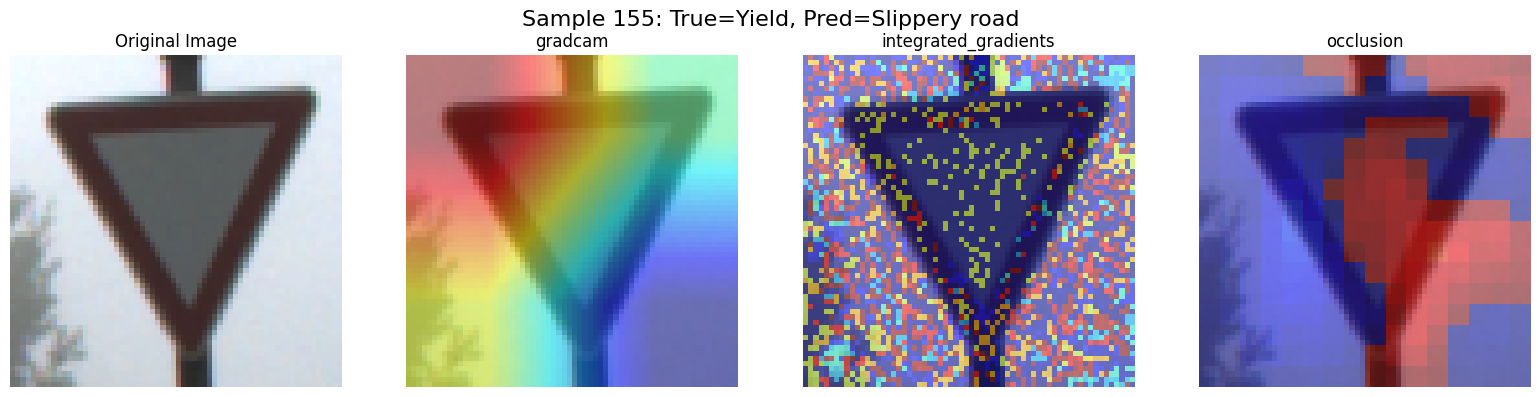

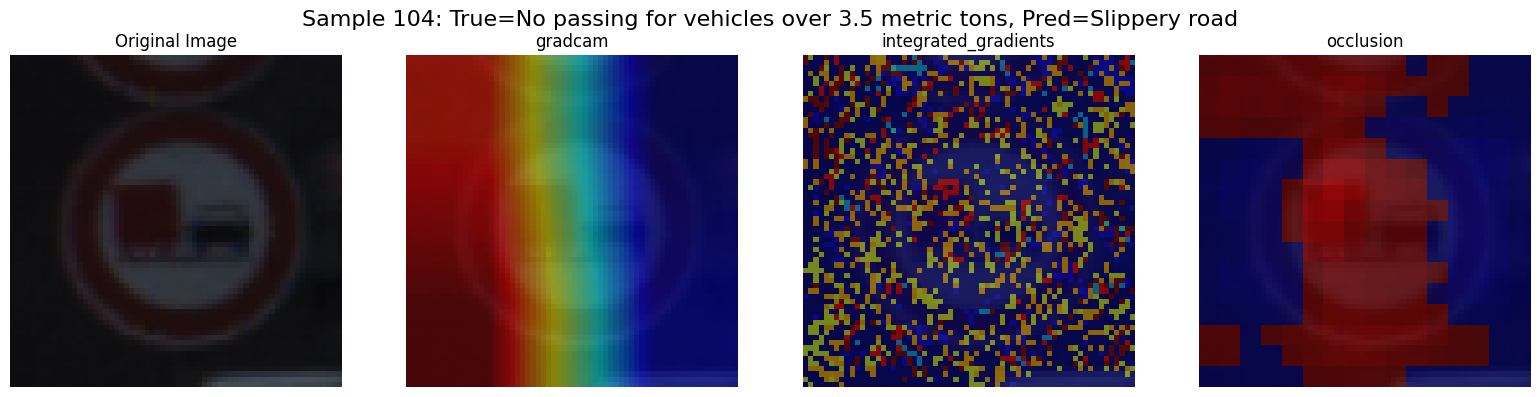


✅ All XAI methods work on multiple samples!


In [14]:
print("Testing on multiple samples...")

num_test_samples = 5
indices = np.random.choice(len(test_dataset), num_test_samples, replace=False)

for idx in indices:
    image, label = test_dataset[idx]
    input_tensor = image.unsqueeze(0).to(device)
    
    # Get prediction
    with torch.no_grad():
        output = model(input_tensor)
        pred = torch.argmax(output, dim=1).item()
    
    # Generate explanations
    results = evaluator.compare_methods(
        input_tensor,
        pred,
        gradcam,
        ig,
        occlusion
    )
    
    # Visualize
    img_denorm = denormalize_image(image)
    plot_xai_comparison(
        img_denorm,
        results,
        title=f'Sample {idx}: True={GTSRB_CLASS_NAMES[label]}, Pred={GTSRB_CLASS_NAMES[pred]}'
    )

print("\nAll XAI methods work on multiple samples!")